In [3]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [4]:
cd C:\Users\yashv\Desktop\Projects

C:\Users\yashv\Desktop\Projects


## Part-1: Data Exploration and Pre-processing

In [5]:
# 1) load the given dataset 

In [6]:
data=pd.read_excel("ML Project 6 - KNN Loan Applicant Credit Risk Analysis.xlsx")

In [7]:
data

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1
...,...,...,...,...,...,...,...
8990,30.80,3,3,0.596748,763,0,0
8991,31.83,3,6,0.986793,532,0,0
8992,32.67,2,5,0.628330,590,0,0
8993,37.00,3,3,0.797193,812,0,0


In [8]:
#2) Check for the null values

In [9]:
data.isnull().sum()

Age                           0
Total Work Experience         0
Number of years in city       0
Cost to Request Ratio         0
Cibil score                   0
Overdrafts past12months       0
Total bounces past12months    0
dtype: int64

In [10]:
 # 3) Get basic information from data 

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         8995 non-null   float64
 1   Total Work Experience       8995 non-null   int64  
 2   Number of years in city     8995 non-null   int64  
 3   Cost to Request Ratio       8995 non-null   float64
 4   Cibil score                 8995 non-null   int64  
 5   Overdrafts past12months     8995 non-null   int64  
 6   Total bounces past12months  8995 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 492.0 KB


In [12]:
data.shape

(8995, 7)

In [13]:
data.describe()

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
count,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,38.808202,2.131073,4.288160,0.831183,752.626570,0.322068,1.162757
std,10.203371,0.892141,1.269416,0.490216,67.645792,0.914998,2.352798
min,18.100000,1.000000,1.000000,0.008466,351.000000,0.000000,0.000000
25%,30.830000,1.000000,3.000000,0.662147,730.000000,0.000000,0.000000
50%,37.200000,2.000000,4.000000,0.800000,768.000000,0.000000,0.000000
75%,45.400000,3.000000,5.000000,0.930908,797.000000,0.000000,1.000000
max,83.800000,5.000000,6.000000,12.006623,882.000000,12.000000,12.000000


In [14]:
data.duplicated().sum()

np.int64(17)

In [15]:
data.drop_duplicates(inplace=True)

In [16]:
data

,Age,Total Work Experience,Number of years in city,Cost to Request Ratio,Cibil score,Overdrafts past12months,Total bounces past12months
0,40.50,2,6,0.842666,594,0,0
1,41.25,5,2,0.791667,754,0,0
2,39.50,5,2,0.727273,779,0,0
3,35.00,1,4,0.820232,818,0,0
4,34.00,3,3,0.455581,853,0,1
...,...,...,...,...,...,...,...
8990,30.80,3,3,0.596748,763,0,0
8991,31.83,3,6,0.986793,532,0,0
8992,32.67,2,5,0.628330,590,0,0
8993,37.00,3,3,0.797193,812,0,0


In [17]:
# 5) Display scatterplot between age & Total work Experience 

Text(0, 0.5, 'Total Work Experience')

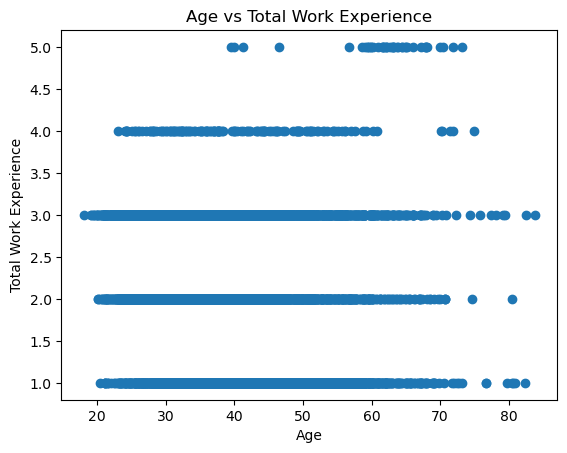

In [18]:
import matplotlib.pyplot as plt 
plt.scatter(data["Age"],data["Total Work Experience"]);
plt.title("Age vs Total Work Experience")
plt.xlabel("Age")
plt.ylabel("Total Work Experience")

In [19]:
# 6) Display box plot for age 

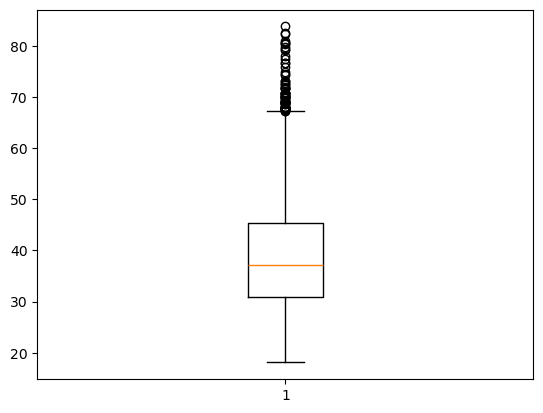

In [20]:
plt.boxplot(data["Age"]);

In [21]:
#7) Display box plot for Cibil score 

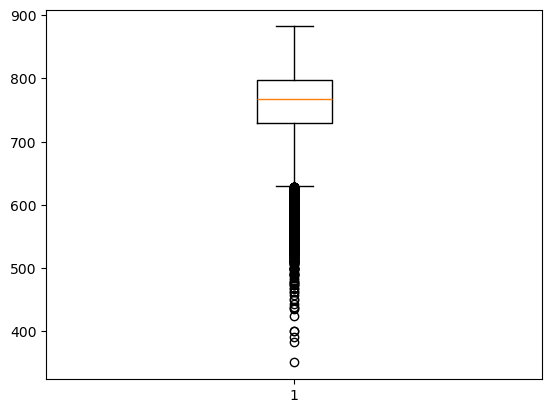

In [22]:
plt.boxplot(data["Cibil score"]);

In [23]:
#8) Create target and features data where target is Total bounces past 12 months

In [24]:
x=data.drop("Total bounces past12months",axis=1)
y=data["Total bounces past12months"]

## Part-2: Working with Model 

In [25]:
#1) Split data into training and testing sets 

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)

In [28]:
# scaling 

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x.columns)  
x_test = pd.DataFrame(scaler.transform(x_test), columns=x.columns)      

In [31]:
# 2)Create a KNN classifier between Features and target data

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
model=KNeighborsClassifier()

In [34]:
model.fit(x_train,y_train)

KNeighborsClassifier()

In [35]:
#3) Display the test score 

In [55]:
print("Training accuracy:",model.score(x_train,y_train)*100) #overfit the model 

Training accuracy: 70.64884433305487


In [56]:
print("Testing accuracy:",model.score(x_test,y_test)*100)

Testing accuracy: 69.20935412026726


In [57]:
yp=model.predict(x_test)

In [58]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [59]:
print("Accuracy score:",accuracy_score(yp,y_test))

Accuracy score: 0.6920935412026726


## Elbow method

In [60]:
training_accuracy=[]
testing_accuracy=[]

for i in range(1,15):
    model=KNeighborsClassifier(i)
    model.fit(x_train,y_train)
    training_accuracy.append(model.score(x_train,y_train))
    testing_accuracy.append(model.score(x_test,y_test))

In [61]:
print(training_accuracy)

[1.0, 0.7891952102478418, 0.7543859649122807, 0.7348927875243665, 0.734057365636313, 0.7258423837371206, 0.7205513784461153, 0.7153996101364523, 0.7128933444722918, 0.7131718184349763, 0.7088554720133667, 0.707880813143971, 0.706766917293233, 0.7064884433305486]


In [62]:
print(testing_accuracy)

[0.5740534521158129, 0.6698218262806236, 0.6653674832962138, 0.6770601336302895, 0.6765033407572383, 0.6854120267260579, 0.6848552338530067, 0.6893095768374164, 0.6909799554565702, 0.6920935412026726, 0.6932071269487751, 0.6948775055679287, 0.6920935412026726, 0.6920935412026726]


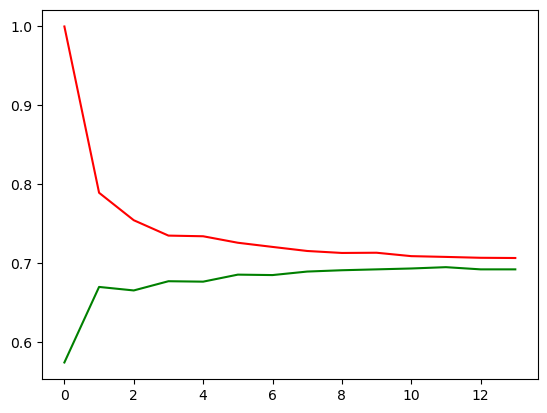

In [63]:
plt.plot(training_accuracy,"r")
plt.plot(testing_accuracy,"g")

In [64]:
final=KNeighborsClassifier(14)

In [65]:
final.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=14)

In [66]:
print("Training accuracy:",final.score(x_train,y_train)*100)

Training accuracy: 70.64884433305487


In [67]:
print("Testing accuracy:",final.score(x_test,y_test)*100)

Testing accuracy: 69.20935412026726


In [68]:
from sklearn.metrics import accuracy_score

In [69]:
yp1=final.predict(x_test)

In [70]:
print("Accuracy score:",accuracy_score(yp1,y_test))

Accuracy score: 0.6920935412026726
